In [1]:
import numpy as np 

import matplotlib.pyplot as plt

from delta_sigma_simulator.modulator import DeltaSigmaModulator
from delta_sigma_simulator.filter import FilterIntegrator, FilterButterworth
from delta_sigma_simulator.quantizer import QuantizerDelayHysteresis
from delta_sigma_simulator.wave import SineWave, BinaryWave

In [2]:
# Example of a 1st-order ASDM with: 
# - Loop filter
loop_filter = FilterIntegrator(5e9)
# - Quantizer
quantizer = QuantizerDelayHysteresis(50e-12, 0.0)
# - SDM
asdm = DeltaSigmaModulator(loop_filter, quantizer)
# - Input frequency
fi = 100e6
# - Input signal
u = SineWave([0, 0.6], fi)
# - Cut-off frequency
fc = 500e6
# - Output filter
output_filter = FilterButterworth(10, fc)
# - Sampling frequency
fs = 4e9
# - Period count
n = 4
# - Time vector
t = 4 / fi + np.arange(0.0, n / fi - 0.5 / fs, 1.0 / fs)
# - Signal bandwidth
fb = 200e6
# - Stop time for the simulation
ts = (4 + n) / fi

In [3]:
def plot_spectrum(v, fi, fs, fb=None, w=None, nb=1):
    # v - Signal to analyze
    # fi - Fundamental frequency
    # fs - Sampling frequency
    # fb - Optional bandwidth for noise power calculation
    # w - Optional window function (callable that takes signal length and returns window)
    # nb - Number of bins per tone
    if fb is None:
        fb = fs / 2

    # Number of samples
    n = len(v)

    if w is not None:
        w = w(n)
    else:
        w = np.ones(n)

    w1 = np.linalg.norm(w, 1)

    f = np.fft.rfftfreq(n, d=1.0 / fs)
    V = np.fft.rfft(w * v) / (w1 / 2)

    bi_center = int(fi / (fs / n))

    # Input tone bins
    bi = (bi_center + np.arange(-(nb - 1) // 2, (nb - 1) // 2 + 1)).astype(int)
    # All other bins
    ba = np.arange(2, fb / (fs / n)).astype(int)

    ba = ba[~np.isin(ba, bi)]

    # Input tone power
    pi = np.sum(np.abs(V[bi]) ** 2)
    # All bins power
    pa = np.sum(np.abs(V[ba]) ** 2)

    sndr = 10 * np.log10(pi / pa)

    plt.title(f"SNDR = {sndr:.2f} dB")
    plt.semilogx(f, 20 * np.log10(np.abs(V)), 'b-', label="Signal")
    plt.axvline(fb, color='k', linestyle='--', label="Bandwidth")
    # plt.ylim(-150, 0)
    plt.grid(which='both')
    plt.legend()
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude [dBFS]')
    plt.show()

In [4]:
# - Simulate ASDM with sine wave input
v = asdm.simulate([u], ts)

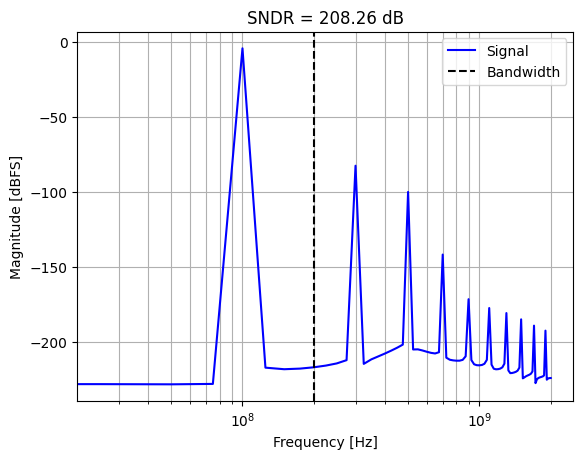

In [5]:
plot_spectrum(output_filter(v)(t), fi, fs, fb, w=np.ones, nb=1)

In [6]:
# - Simulate with a binary wave input
w = asdm.simulate([v], ts)

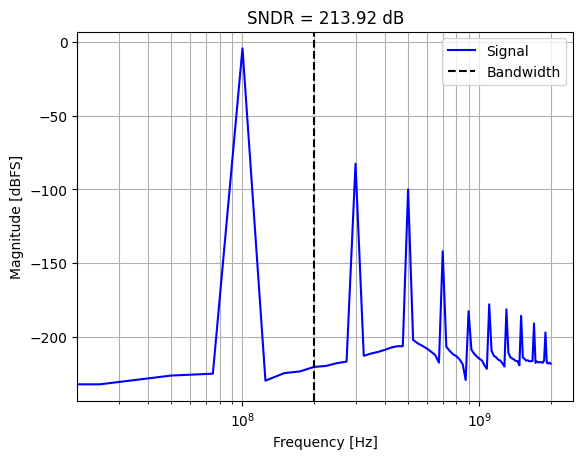

In [7]:
plot_spectrum(output_filter(w)(t), fi, fs, fb, w=np.ones, nb=1)

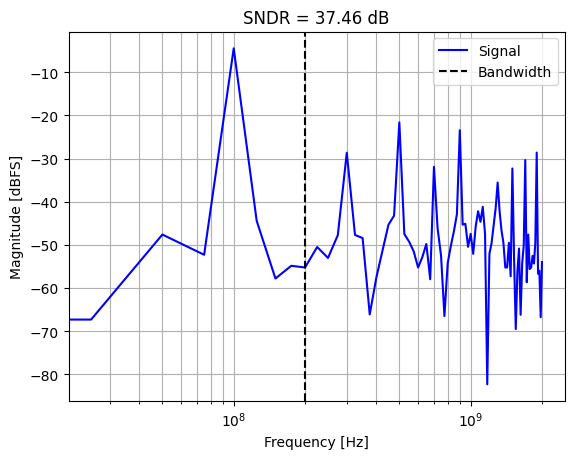

In [8]:
class ADC:
    def __init__(self, fs, n, tau):
        # - Sampling frequency
        self.fs = fs
        # - Number of stages
        self.n = n
        # - Delay
        self.tau = tau
    
    def __call__(self, e, t):
        v = np.zeros_like(t)

        for i in range(self.n):
            v += e(t - i * self.tau)

        v /= self.n

        return v

adc = ADC(4e9, 25, 20e-12)

# - Plot spectrum
plot_spectrum(adc(v, t), fi, adc.fs, fb, w=np.ones, nb=1)